# Rice Leaf Disease Classification using CNN

## Capstone Project (PRCP-1001)

### Submitted By
**Name:** P Satyashry

### Problem Statement

Rice is one of the most important food crops worldwide. However, various leaf diseases significantly reduce crop yield and quality. Early identification of these diseases can help farmers take timely preventive measures.

The objective of this project is to develop a deep learning model capable of automatically classifying rice leaf diseases from leaf images.

---

## Objectives

- Perform Exploratory Data Analysis (EDA) on the dataset.
- Preprocess rice leaf images for model training.
- Apply Data Augmentation techniques.
- Train multiple deep learning models.
- Compare model performance.
- Recommend the best model for production deployment.

# 1. Import Required Libraries

In [1]:
# Basic Libraries
import os
import warnings
import random

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
warnings.filterwarnings("ignore")

# 2. Dataset Loading and Understanding

Before building any machine learning or deep learning model, it is important to understand the dataset. In this section, we will:

- Load the dataset.
- Identify the disease classes.
- Count the number of images in each class.
- Verify whether the dataset is balanced.

In [2]:
dataset_path = "data"

classes = sorted(os.listdir(dataset_path))

print("Disease Classes:\n")

for cls in classes:
    print(cls)

Disease Classes:

Bacterial leaf blight
Brown spot
Leaf smut


In [3]:
# Image Count
image_counts = {}

for cls in classes:
    folder_path = os.path.join(dataset_path, cls)

    count = len([
        file for file in os.listdir(folder_path)
        if file.endswith((".jpg", ".jpeg", ".png", ".JPG"))
    ])

    image_counts[cls] = count
image_counts

{'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 39}

In [4]:
dataset_info = pd.DataFrame({
    "Disease": image_counts.keys(),
    "Number of Images": image_counts.values()
})

dataset_info

,Disease,Number of Images
0,Bacterial leaf blight,40
1,Brown spot,40
2,Leaf smut,39


In [5]:
# Display total Images
total_images = dataset_info["Number of Images"].sum()

print(f"Total Images: {total_images}")

Total Images: 119


## Observation

- The dataset contains three rice leaf disease classes:
  - Bacterial Leaf Blight
  - Brown Spot
  - Leaf Smut
- Bacterial Leaf Blight contains **40** images.
- Brown Spot contains **40** images.
- Leaf Smut contains **39** images.
- The dataset contains a total of **119** images.
- Although the assignment mentions 120 images, the downloaded dataset contains 119 images. The analysis and model development in this notebook are based on the available dataset.

# 3. Exploratory Data Analysis (EDA)

### Sample Images from Each Disease Class

Visualizing sample images helps us understand the appearance of each disease class. This provides an initial understanding of the dataset and highlights any visible differences among the classes.

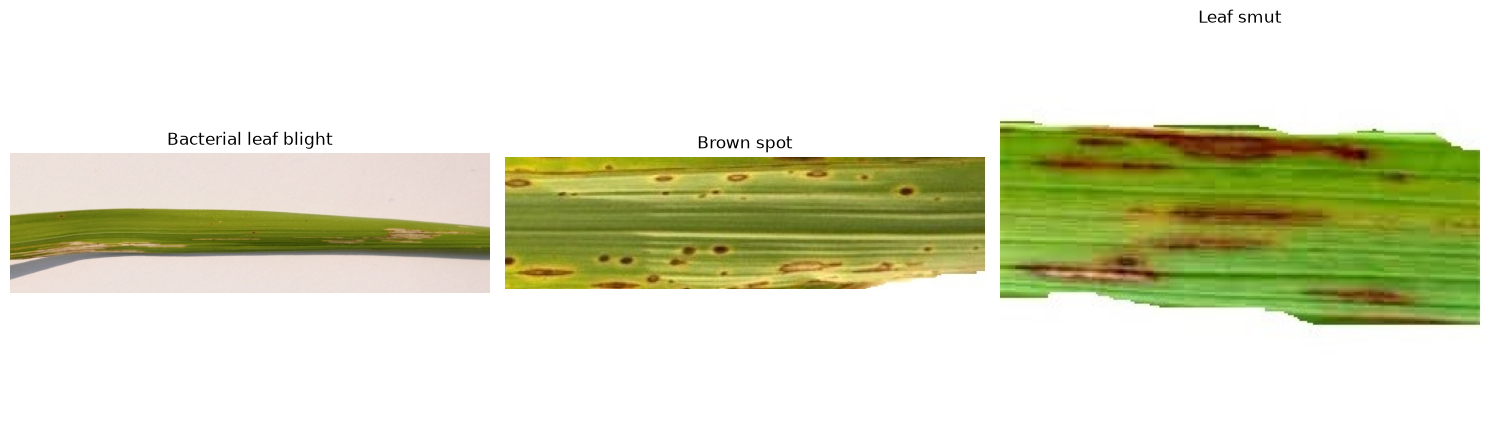

In [6]:
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, cls in enumerate(classes):
    folder_path = os.path.join(dataset_path, cls)

    image_name = random.choice(os.listdir(folder_path))
    image_path = os.path.join(folder_path, image_name)

    img = plt.imread(image_path)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Observation

- One sample image from each disease class is displayed.
- The visual appearance of the diseased leaves varies across the three categories.
- These differences provide useful information that the machine learning and deep learning models can learn during training.

### Image Dimension Analysis

The images in the dataset may have different heights and widths. Before training a model, it is important to inspect the image dimensions to determine whether resizing is required.

In [7]:
image_sizes = []

for cls in classes:
    folder_path = os.path.join(dataset_path, cls)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        img = plt.imread(image_path)

        height, width = img.shape[:2]

        image_sizes.append([cls, width, height])

image_size_df = pd.DataFrame(
    image_sizes,
    columns=["Disease", "Width", "Height"]
)

image_size_df.head()

,Disease,Width,Height
0,Bacterial leaf blight,3081,897
1,Bacterial leaf blight,3081,897
2,Bacterial leaf blight,3081,897
3,Bacterial leaf blight,3081,897
4,Bacterial leaf blight,3081,897


In [8]:
image_size_df.tail()

,Disease,Width,Height
114,Leaf smut,250,200
115,Leaf smut,510,383
116,Leaf smut,565,233
117,Leaf smut,562,217
118,Leaf smut,741,291


In [9]:
image_size_df.describe()

,Width,Height
count,119.000000,119.000000
mean,2383.638655,707.739496
std,1123.528972,311.657582
min,250.000000,71.000000
25%,1074.000000,377.000000
50%,3081.000000,897.000000
75%,3081.000000,897.000000
max,3081.000000,900.000000


In [10]:
image_size_df["Width"].max()

np.int64(3081)

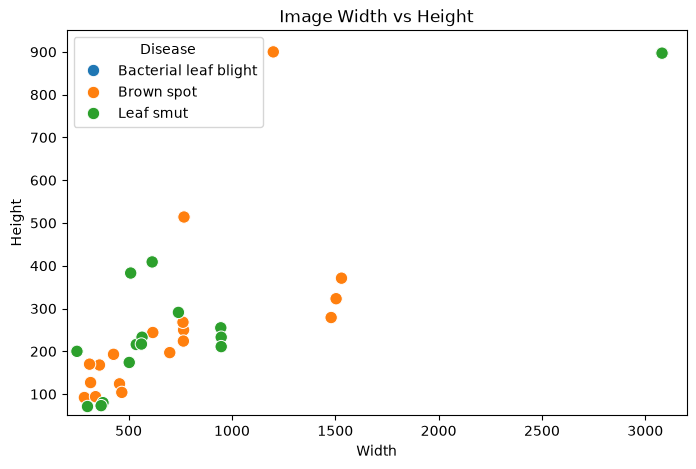

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=image_size_df,
    x="Width",
    y="Height",
    hue="Disease",
    s=80
)

plt.xlim(200, 3200)
plt.ylim(50, 950)

plt.title("Image Width vs Height")
plt.show()

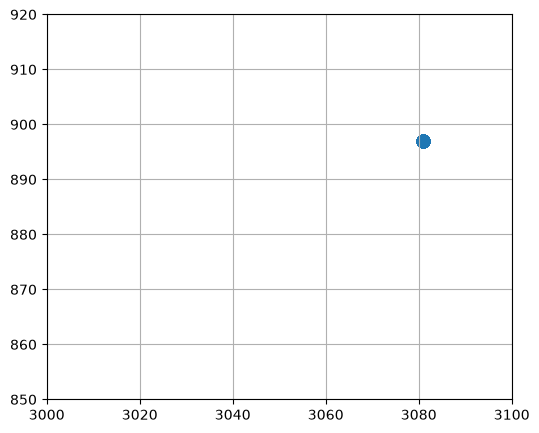

In [12]:
blight = image_size_df[image_size_df["Disease"] == "Bacterial leaf blight"]

plt.figure(figsize=(6,5))
plt.scatter(blight["Width"], blight["Height"], s=80)
plt.xlim(3000, 3100)
plt.ylim(850, 920)
plt.grid(True)
plt.show()

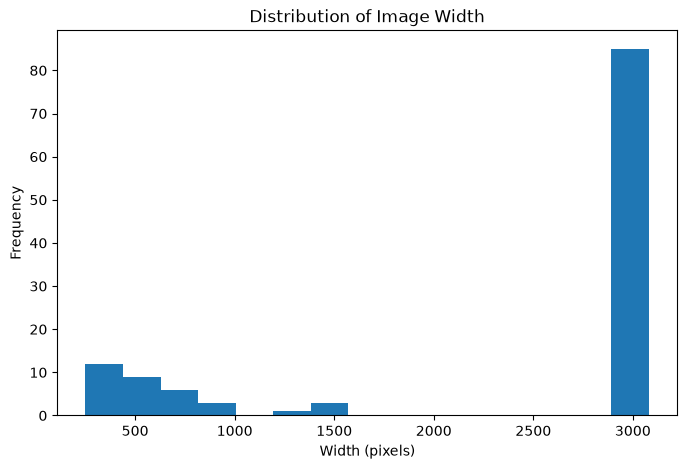

In [13]:
plt.figure(figsize=(8,5))

plt.hist(image_size_df["Width"], bins=15)

plt.title("Distribution of Image Width")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.show()

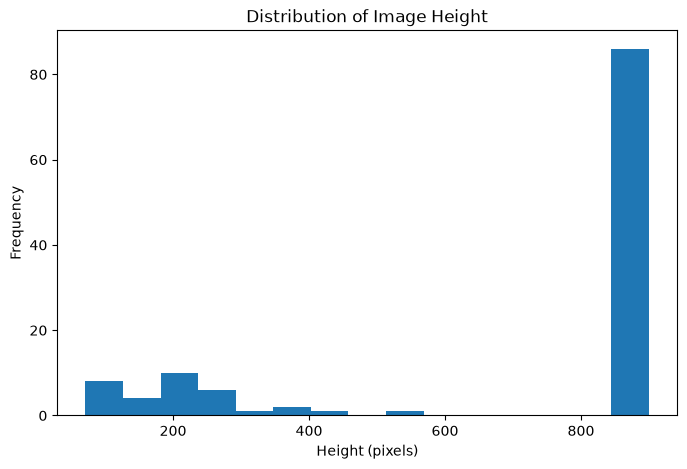

In [14]:
plt.figure(figsize=(8,5))

plt.hist(image_size_df["Height"], bins=15)

plt.title("Distribution of Image Height")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.show()

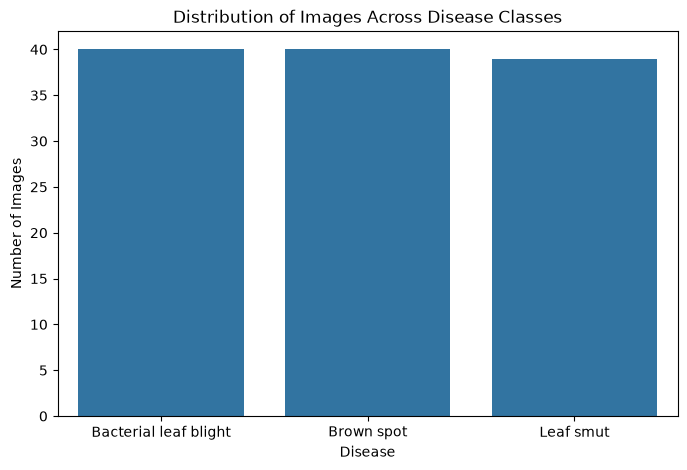

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=dataset_info,
    x="Disease",
    y="Number of Images"
)

plt.title("Distribution of Images Across Disease Classes")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.show()

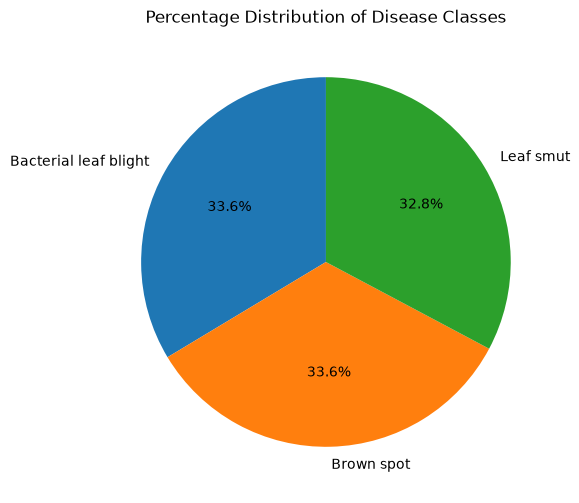

In [16]:
plt.figure(figsize=(6,6))

plt.pie(
    dataset_info["Number of Images"],
    labels=dataset_info["Disease"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Disease Classes")

plt.show()

## Observation

- The dataset contains images with varying widths and heights across the three disease classes.
- Most images have relatively small dimensions, while a few images have significantly higher resolutions.
- Some images share identical dimensions, resulting in overlapping points in the scatter plot.
- Since the image sizes are inconsistent, all images will be resized to a fixed dimension during the preprocessing stage to ensure uniform input for the machine learning and deep learning models.
- The pie chart confirms that the dataset is almost evenly distributed among the three disease classes. Each class contributes approximately one-third of the total dataset, indicating a well-balanced dataset for classification.

# 4. Data Preprocessing

##  Load Images and Create Labels

In this step, all images are loaded from their respective class folders, resized to a fixed dimension of 128 × 128 pixels, and converted into NumPy arrays. Each image is assigned a numerical label based on its disease class.

In [17]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Image size
IMG_SIZE = (128, 128)

# Lists to store images and labels
images = []
labels = []

# Label mapping
label_map = {
    "Bacterial leaf blight": 0,
    "Brown spot": 1,
    "Leaf smut": 2
}

# Load images
for disease in classes:

    folder_path = os.path.join(dataset_path, disease)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        img = load_img(image_path, target_size=IMG_SIZE)

        img_array = img_to_array(img)

        images.append(img_array)

        labels.append(label_map[disease])

# Convert to NumPy arrays
X = np.array(images)
y = np.array(labels)

print("Image Data Shape :", X.shape)
print("Label Shape :", y.shape)

Image Data Shape : (119, 128, 128, 3)
Label Shape : (119,)


## Observation

- All images were successfully loaded and resized to **128 × 128** pixels.
- The images were converted into NumPy arrays.
- Numerical labels were assigned to each disease class.
- The dataset is now ready for normalization and model preparation.

## Image Normalization

The pixel values of images range from 0 to 255. Neural networks generally perform better when the input values are scaled to a smaller range. Therefore, the pixel values are normalized to the range **0 to 1** by dividing each pixel by 255.

In [18]:
X = X / 255.0

print("Minimum Pixel Value :", X.min())
print("Maximum Pixel Value :", X.max())

#The pixel values have been successfully normalized from the range **0–255** to **0–1**. This helps improve the stability and convergence of deep learning models during training.

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


##  Label Distribution

The numerical labels assigned to each disease class are verified to ensure that the dataset has been labeled correctly before model training.

In [19]:
label_names = {
    0: "Bacterial leaf blight",
    1: "Brown spot",
    2: "Leaf smut"
}

label_counts = pd.Series(y).value_counts().sort_index()

for label, count in label_counts.items():
    print(f"{label_names[label]} : {count}")

Bacterial leaf blight : 40
Brown spot : 40
Leaf smut : 39


In [20]:
# Split the data 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (95, 128, 128, 3)
Testing Images : (24, 128, 128, 3)
